# Init

In [99]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text

import numpy as np
import pandas as pd
import ast

from src import paths


from src.utils import interactive_dataframe_selector

In [ ]:
from src import paths

og_df = pd.read_parquet(paths.PROCESSED_DATA_DIR /
                        'BARTER_DEALS_MODEL_READY.parquet')

In [101]:
# Load environment variables from .env file
load_dotenv("../private_data/.env")

host = os.getenv("HOST")
db = os.getenv("DB")
port = os.getenv("PORT")
role = os.getenv("ROLE")
pw = os.getenv("PASSWORD")
engine = create_engine(f"postgresql+psycopg2://{role}:{pw}@{host}:{port}/{db}")

In [ ]:
query = """
    SELECT * FROM public.deal_activity_logs 
    WHERE action = 'DEAL_UPDATE';
"""
# update_logs_df = pd.read_sql(query, con=your_db_connection)

df = pd.read_sql(query, engine)

In [ ]:
import pandas as pd
import json


def parse_json_safely(val):
    """Safely parse JSON strings into Python dictionaries."""
    if pd.isna(val) or not val:
        return {}
    if isinstance(val, str):
        try:
            return json.loads(val)
        except json.JSONDecodeError:
            return {}
    return val


def get_dict_diff(before_dict, after_dict):
    """Recursively compares two dictionaries and returns the differences."""
    diff = {}

    # 1. Check for modified or added keys
    for k, v in after_dict.items():
        if k not in before_dict:
            diff[k] = {'old': None, 'new': v}
        elif before_dict[k] != v:
            # If both are dictionaries, recurse deeper
            if isinstance(v, dict) and isinstance(before_dict[k], dict):
                nested_diff = get_dict_diff(before_dict[k], v)
                if nested_diff:  # Only add if there are actual differences inside
                    diff[k] = nested_diff
            else:
                diff[k] = {'old': before_dict[k], 'new': v}

    # 2. Check for removed keys
    for k, v in before_dict.items():
        if k not in after_dict:
            diff[k] = {'old': v, 'new': None}

    return diff


def compute_row_diff(row):
    """Wrapper to parse the rows and compute the diff, ignoring outer wrappers."""
    before = parse_json_safely(row.get('before', {}))
    after = parse_json_safely(row.get('after', {}))

    # Your payloads nest the actual data inside a 'deal' key.
    # Let's un-nest it to make the diff cleaner to read.
    before_data = before.get('deal', before)
    after_data = after.get('deal', after)

    # Calculate differences
    changes = get_dict_diff(before_data, after_data)

    # Optional: Filter out noisy mechanical keys that always update but don't matter to the market
    noise_keys = ['updated_at', 'version', 'SoftDeletable']
    for key in noise_keys:
        changes.pop(key, None)

    return changes

# ==========================================
# Execution
# ==========================================


# Assuming your dataframe is called logs_df
df['changes'] = df.apply(compute_row_diff, axis=1)

# Let's drop rows where nothing meaningful changed (empty dictionaries)
meaningful_updates = df[df['changes'].astype(bool)].copy()

# Look at the first 5 meaningful updates to see exactly what the brands changed
for idx, row in meaningful_updates.head(5).iterrows():
    print(
        f"\n--- Deal ID: {row.get('deal_id', 'Unknown')} | Action Date: {row.get('created_at', 'Unknown')} ---")
    print(json.dumps(row['changes'], indent=2, ensure_ascii=False))


--- Deal ID: Unknown | Action Date: 2025-06-14 04:00:00.320670 ---
{
  "content_type_ids": {
    "old": null,
    "new": [
      37,
      29,
      20,
      21
    ]
  },
  "content_types": {
    "old": null,
    "new": [
      {
        "updated_at": "2025-05-01T11:35:38.277381Z",
        "id": 37,
        "name": "Luxury",
        "slug": "Sketch-Logo"
      },
      {
        "updated_at": "2025-05-01T11:36:20.952338Z",
        "id": 29,
        "name": "UGC",
        "slug": "Film-Strip"
      },
      {
        "id": 20,
        "name": "Beauty",
        "slug": "Heart"
      },
      {
        "id": 21,
        "name": "Fashion",
        "slug": "Dress"
      }
    ]
  },
  "partner": {
    "old": null,
    "new": {
      "SoftDeletable": {},
      "customer_id": "cus_SGgudQJNAVL4Ly",
      "id": 1658,
      "kvk": "",
      "name": "NaturylExtensions",
      "status": "",
      "tags": null,
      "user_id": 41602,
      "vat": ""
    }
  },
  "social_media_requirement": {
  

In [ ]:
import pandas as pd
import json


def extract_status(payload):
    """Safely extracts the 'status' field from the nested deal payload."""
    if pd.isna(payload) or not payload:
        return None

    # Parse if it's a string
    if isinstance(payload, str):
        try:
            data = json.loads(payload)
        except json.JSONDecodeError:
            return None
    else:
        data = payload

    # Safely navigate to deal -> status
    if isinstance(data, dict):
        return data.get('deal', {}).get('status')
    return None


def get_status_transitions(logs_df: pd.DataFrame) -> pd.DataFrame:
    """
    Parses the logs to detect exactly when a deal's status changed,
    returning a clean dataframe of the transitions.
    """
    df = logs_df.copy()

    # 1. Extract statuses
    df['old_status'] = df['before'].apply(extract_status)
    df['new_status'] = df['after'].apply(extract_status)

    # 2. Keep only rows where the status actually changed
    # (We ignore NaNs equating to NaNs, and identical statuses)
    transitions = df[
        (df['old_status'] != df['new_status']) &
        (df['old_status'].notna() | df['new_status'].notna())
    ].copy()

    # 3. Clean up the output
    # Assuming the action timestamp is in 'created_at' in the logs_df
    result = transitions[['entity_id',
                          'created_at', 'old_status', 'new_status']]

    # Sort chronologically per deal
    result = result.sort_values(
        by=['entity_id', 'created_at']).reset_index(drop=True)

    # Rename for absolute clarity
    result = result.rename(columns={'created_at': 'transition_time'})

    return result

# ==========================================
# Execution
# ==========================================


# Assuming your raw SQL pull is named `logs_df`
status_history = get_status_transitions(df)

# Look at the transitions!
print(f"Detected {len(status_history)} status transitions.")
print(status_history.head(15))

# You can also aggregate this to see the most common pathways:
# e.g., how many went straight from 'draft' to 'published' vs 'ready' to 'published'
print("\n--- Most Common Status Pathways ---")
pathways = status_history.groupby(
    ['old_status', 'new_status']).size().reset_index(name='count')
print(pathways.sort_values('count', ascending=False))

Detected 12342 status transitions.
                               entity_id            transition_time  \
0   019689e1-dadd-00c8-5101-e0d07384f6dd 2025-08-21 04:00:13.480321   
1   019689e1-dadd-00c8-5101-e0d07384f6dd 2025-08-21 04:00:13.528029   
2   019689e1-de33-00c8-297c-7a4241d57de4 2025-09-25 09:53:28.894824   
3   019689e1-e23f-00c8-d754-c3e992ead0d8 2025-09-23 04:00:11.528685   
4   019689e1-e23f-00c8-d754-c3e992ead0d8 2025-09-23 04:00:11.572618   
5   019689e1-e3d7-00c8-2ee9-d52ab1dc434e 2025-09-25 09:53:33.031588   
6   019689e1-e796-00c8-dfeb-bc61800dd2d8 2025-07-11 09:08:59.780444   
7   019689e1-e796-00c8-dfeb-bc61800dd2d8 2025-07-11 09:08:59.900171   
8   019689e1-e94a-00c8-d860-fccce5580ced 2025-07-10 10:39:33.914307   
9   019689e1-e94a-00c8-d860-fccce5580ced 2025-07-10 10:39:34.024992   
10  019689e1-ea95-00c8-7bbf-9caeb3ade750 2026-03-11 04:00:05.802730   
11  019689e1-ea95-00c8-7bbf-9caeb3ade750 2026-03-11 04:00:06.079525   
12  019689e1-eb74-00c8-81a9-274d25796041 2

In [ ]:
print(status_history.loc[status_history['entity_id'] ==
      '01970429-61af-00c8-65d9-84e51d6fa412', ['transition_time', 'old_status', 'new_status']])

                transition_time old_status new_status
2340 2025-05-24 21:18:30.507966      ready       live
2341 2025-05-24 21:19:22.344544       live   finished
2342 2025-05-24 21:22:47.963961   finished      draft
2343 2025-05-24 21:22:51.264218      draft      ready
2344 2025-05-24 21:22:51.362578      ready       live
2345 2025-06-25 13:11:22.141139       live   inactive
2346 2025-10-10 21:59:28.450228   inactive   archived
2347 2025-10-10 21:59:38.200070   archived    trashed


In [ ]:
import pandas as pd

# 1. Ensure entity_id is mapped correctly to deal_id as a string
status_history['deal_id'] = status_history['entity_id'].astype(str)

# 2. Filter strictly for events where the deal transitioned INTO 'published'
published_events = status_history[status_history['new_status'] == 'live'].copy(
)

# Sort chronologically to ensure the lists are in order
published_events = published_events.sort_values(
    by=['deal_id', 'transition_time'])

# 3. Aggregate into lists per deal
publish_times_df = published_events.groupby('deal_id').agg(
    publish_times=('transition_time', list),
    publish_count=('transition_time', 'count')
).reset_index()

# 4. Data Quality Diagnostics
total_published = len(publish_times_df)
multi_publish = len(publish_times_df[publish_times_df['publish_count'] > 1])

print("--- Data Quality: Publish Events ---")
print(f"Deals with at least one publish event: {total_published}")
print(f"Deals published MULTIPLE times: {multi_publish}")
print(
    f"Percentage of multi-publish deals: {(multi_publish / total_published * 100):.2f}%\n")

# 5. Let's inspect the anomalies (the ones published multiple times)
anomalies = publish_times_df[publish_times_df['publish_count'] > 1].sort_values(
    'publish_count', ascending=False)

print("--- Top Deals with Multiple Publish Events ---")
for idx, row in anomalies.head(5).iterrows():
    print(f"Deal ID: {row['deal_id']} | Count: {row['publish_count']}")
    # Print the exact timestamps to see how far apart they are
    for t in row['publish_times']:
        print(f"  - {t}")
    print()

--- Data Quality: Publish Events ---
Deals with at least one publish event: 3965
Deals published MULTIPLE times: 279
Percentage of multi-publish deals: 7.04%

--- Top Deals with Multiple Publish Events ---
Deal ID: 019ba2b3-9347-00c8-ca93-0150c41e9ecf | Count: 17
  - 2026-01-09 12:20:36.620753
  - 2026-01-19 13:09:22.375644
  - 2026-02-01 14:17:43.911596
  - 2026-02-18 09:04:47.741936
  - 2026-02-20 12:57:58.253580
  - 2026-03-01 21:08:33.066734
  - 2026-03-01 21:09:26.020786
  - 2026-03-02 10:29:46.324089
  - 2026-03-03 14:43:24.086548
  - 2026-03-04 10:57:18.520770
  - 2026-03-04 11:03:36.991181
  - 2026-03-04 11:04:20.425232
  - 2026-03-04 11:57:16.855452
  - 2026-03-04 13:07:46.184554
  - 2026-03-05 15:44:24.627716
  - 2026-03-09 14:58:35.918218
  - 2026-03-19 18:34:20.709728

Deal ID: 019c1eb2-3e70-00c8-219f-23215d3979de | Count: 11
  - 2026-02-02 14:12:04.093437
  - 2026-02-16 09:59:46.978419
  - 2026-02-16 10:10:12.544250
  - 2026-02-16 10:13:09.313249
  - 2026-02-19 11:59:12.63

In [ ]:
import pandas as pd
import numpy as np


def get_first_epoch_bounds(status_history: pd.DataFrame, df_deals: pd.DataFrame) -> pd.DataFrame:
    """
    Finds the first time a deal went live, and the first time it was taken down.
    """
    df = status_history.copy()

    # 1. Find the FIRST time it became 'live'
    first_live = df[df['new_status'] == 'live'].drop_duplicates(
        subset=['deal_id'], keep='first')
    first_live = first_live[['deal_id', 'transition_time']].rename(
        columns={'transition_time': 'first_live_at'})

    # 2. Merge back to the history to find events that happened AFTER first_live_at
    df_post_live = df.merge(first_live, on='deal_id', how='inner')
    df_post_live = df_post_live[df_post_live['transition_time']
                                > df_post_live['first_live_at']]

    # 3. Find the FIRST time the status changed to something else (e.g., paused, closed, draft)
    first_interrupt = df_post_live[df_post_live['new_status'] != 'live'].drop_duplicates(
        subset=['deal_id'], keep='first')
    first_interrupt = first_interrupt[['deal_id', 'transition_time']].rename(
        columns={'transition_time': 'first_interrupted_at'})

    # 4. Merge into a clean mapping dataframe
    bounds_df = df_deals[['deal_id', 'created_at']].copy()
    bounds_df['deal_id'] = bounds_df['deal_id'].astype(str)

    bounds_df = bounds_df.merge(first_live, on='deal_id', how='left')
    bounds_df = bounds_df.merge(first_interrupt, on='deal_id', how='left')

    # Fallback: If no 'published' event is found, assume it went live at 'created_at'
    bounds_df['first_live_at'] = bounds_df['first_live_at'].fillna(
        bounds_df['created_at'])

    # Make sure all datetime formats match (e.g., UTC)
    bounds_df['first_live_at'] = pd.to_datetime(
        bounds_df['first_live_at'], utc=True)
    bounds_df['first_interrupted_at'] = pd.to_datetime(
        bounds_df['first_interrupted_at'], utc=True)

    return bounds_df


# Execute
epoch_bounds = get_first_epoch_bounds(status_history, og_df)
og_df = og_df.drop(columns=['first_live_at', 'first_interrupted_at'], errors='ignore').merge(
    epoch_bounds[['deal_id', 'first_live_at', 'first_interrupted_at']], on='deal_id', how='left'
)

In [ ]:
# 1. Force created_at to be timezone-aware (UTC) to match first_live_at
og_df['created_at'] = pd.to_datetime(og_df['created_at'], utc=True)

# 2. Now the subtraction will work perfectly
og_df['diff_live_created'] = og_df['first_live_at'] - og_df['created_at']
og_df['diff_live_interrupted'] = og_df['first_interrupted_at'] - \
    og_df['first_live_at']

# 3. (Optional) Convert that difference into a readable float like hours or days
og_df['hours_to_live'] = og_df['diff_live_created'].dt.total_seconds() / 3600
og_df['hours_to_interrupted'] = og_df['diff_live_interrupted'].dt.total_seconds() / \
    3600


# Check how long deals typically sit in draft before going live!
print(og_df['hours_to_live'].describe())

count    3139.000000
mean       12.649689
std        89.617082
min         0.000025
25%         0.000053
50%         0.000067
75%         0.049557
max      2154.728095
Name: hours_to_live, dtype: float64


In [ ]:
og_df.applicants_applications_count

In [129]:
og_df[og_df['hours_to_interrupted'] < 7*24]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,log_title_word_count,log_text_word_count,log_requirements_word_count,log_competitor_density,first_live_at,first_interrupted_at,diff_live_created,hours_to_live,diff_live_interrupted,hours_to_interrupted
13,3,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",0196903c-67b6-00c8-7608-97e95e910915,uploads/deals/019690cf-5657-ffff-3680-8aadef2d...,1500,None,2025-05-02 11:44:15.179431,2025-05-02 12:27:50.182374,2025-05-04 19:54:29.650484,"[{""id"": ""01KERHWJC205FPXPYE4S4WZM9F"", ""name"": ...",...,2.302585,3.258097,1.609438,0.693147,2025-05-02 11:44:15.243968+00:00,2025-05-07 22:01:09.165512+00:00,0 days 02:40:55.253183,2.682015,5 days 10:16:53.921544,130.281645
16,35,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019690c3-c0e5-00c8-9cd1-3f1c4bc9066e,uploads/deals/019690ca-fc86-ffff-fc8d-d4d1bbe3...,2500,None,2025-05-02 11:40:29.591407,2025-05-02 23:29:18.219161,2025-08-29 07:39:44.003052,"[{""id"": ""01KERHW1WM05FZ53ZKE30AWGV4"", ""name"": ...",...,1.791759,4.143135,3.737670,0.000000,2025-05-02 11:40:10.195697+00:00,2025-05-02 11:40:11.740037+00:00,0 days 00:09:00.014435,0.150004,0 days 00:00:01.544340,0.000429
17,22,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}]",019690cf-5c91-00c8-5ea3-5bc835e46c95,uploads/deals/019690ce-4752-ffff-b009-3d6bb33c...,1500,None,2025-05-02 11:43:51.060505,2025-05-02 13:16:15.617337,2025-05-03 16:21:51.991715,None,...,2.079442,3.871201,1.098612,0.693147,2025-05-02 11:43:51.123280+00:00,2025-05-03 16:33:46.179660+00:00,0 days 00:00:00.193749,0.000054,1 days 04:49:55.056380,28.831960
38,3,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",0196a0b5-c1bd-00c8-6a3c-01bf722256fe,uploads/deals/0196a0b4-8bb8-ffff-faa8-5a68ea1a...,1500,None,2025-05-05 13:49:48.488577,2025-05-06 09:46:57.116454,2025-05-06 22:26:20.491007,"[{""id"": ""01KERHWJC205FPXPYE4S4WZM9F"", ""name"": ...",...,2.079442,3.637586,1.609438,0.693147,2025-05-05 13:49:48.545644+00:00,2025-05-07 22:01:09.217624+00:00,0 days 00:00:00.195710,0.000054,2 days 08:11:20.671980,56.189076
55,25,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",0196a5a1-9c32-00c8-a20a-c1c87173d313,uploads/deals/0196a59d-8cda-ffff-cb83-c1cc0407...,5000,None,2025-07-23 15:01:00.838671,2025-05-06 14:10:53.094302,2025-05-11 07:59:15.295490,None,...,1.945910,3.401197,3.091042,1.791759,2025-05-06 12:45:54.359255+00:00,2025-05-11 16:00:16.057453+00:00,0 days 00:00:00.260515,0.000072,5 days 03:14:21.698198,123.239361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3065,6,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019c9f29-c377-00c8-b175-5581d4e7fefc,uploads/deals/019c9f2d-1e1f-ffff-bff0-65a15bd8...,1500,None,2026-02-27 12:59:16.884736,2026-02-27 14:59:48.901085,2026-03-02 16:31:42.746541,"[{""id"": ""01KJFDZVQX05FZ90E50QYE0Y79"", ""name"": ...",...,1.609438,5.153292,4.382027,1.609438,2026-02-27 12:59:16.915233+00:00,2026-03-05 11:40:07.887619+00:00,0 days 00:05:16.603870,0.087946,5 days 22:40:50.972386,142.680826
3085,1,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019cb390-ee98-00c8-c344-70e629b892bf,uploads/deals/019cb38e-20a3-ffff-4e9d-5bfb9704...,2500,None,2026-03-03 11:59:05.984627,2026-03-03 18:41:36.619107,2026-03-03 18:41:36.619107,None,...,1.791759,2.639057,1.791759,1.386294,2026-03-03 11:59:06.006907+00:00,2026-03-03 19:00:16.754403+00:00,0 days 00:00:00.126088,0.000035,0 days 07:01:10.747496,7.019652
3117,28,"[{'id': 25, 'name': 'Cooking', 'slug': 'Cookin...",019cc33c-535f-00c8-9839-4c421aa1e0d0,uploads/deals/019cc2c1-d8e9-ffff-a79e-03e26ab7...,1500,None,2026-03-06 13:00:36.683523,2026-03-06 13:15:28.589067,2026-03-10 08:54:08.030090,"[{""id"": ""01KJZ80ZY305FV7RZQAHT0R7GZ"", ""name"": ...",...,2.197225,3.044522,2.708050,0.693147,2026-03-06 13:00:36.709863+00:00,2026-03-10 09:26:47.599256+00:00,0 days 00:00:00.134745,0.000037,3 days

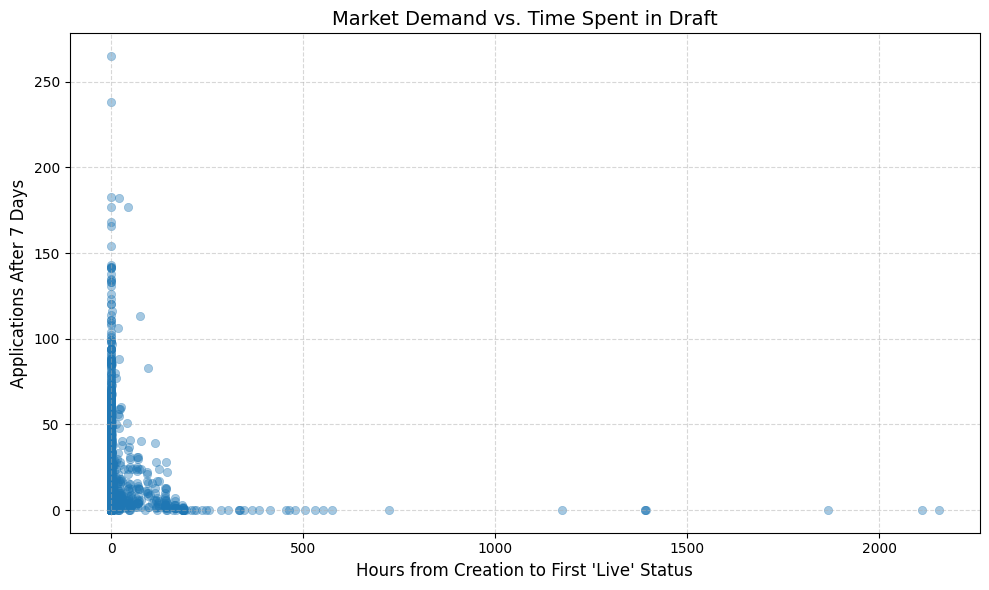

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the scatter plot
sns.scatterplot(
    data=og_df,
    x='hours_to_live',
    y='apps_after_7_days',
    alpha=0.4,
    edgecolor=None,
    ax=ax
)

# Formatting for readability
ax.set_title("Market Demand vs. Time Spent in Draft", fontsize=14)
ax.set_xlabel("Hours from Creation to First 'Live' Status", fontsize=12)
ax.set_ylabel("Applications After 7 Days", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

# Optional: If the data is incredibly skewed, uncomment the lines below to use log scales
# ax.set_xscale('log')
# ax.set_yscale('symlog') # symlog allows 0 values, standard log does not

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Get first_live_at for each deal
first_live = status_history[status_history['new_status']
                            == 'live'].drop_duplicates('deal_id', keep='first')
first_live = first_live[['deal_id', 'transition_time']].rename(
    columns={'transition_time': 'first_live_at'})

# Create a temporary dataframe for the math
temp_df = og_df[['deal_id', 'created_at']].copy()
temp_df['deal_id'] = temp_df['deal_id'].astype(str)
temp_df = temp_df.merge(first_live, on='deal_id', how='left')

# Fallback to created_at if no live transition exists, ensure UTC
temp_df['first_live_at'] = pd.to_datetime(
    temp_df['first_live_at'].fillna(temp_df['created_at']), utc=True)
temp_df['cutoff_time'] = temp_df['first_live_at'] + pd.Timedelta(days=7)

# 2. Process logs
logs = status_history.copy()
logs['deal_id'] = logs['deal_id'].astype(str)
logs['transition_time'] = pd.to_datetime(logs['transition_time'], utc=True)

# Sort to calculate durations
logs = logs.sort_values(['deal_id', 'transition_time'])
logs['next_transition_time'] = logs.groupby(
    'deal_id')['transition_time'].shift(-1)

# Merge the 7-day boundary
logs = logs.merge(
    temp_df[['deal_id', 'first_live_at', 'cutoff_time']], on='deal_id', how='inner')

# Filter to only transitions that happened BEFORE the 7-day cutoff
logs = logs[logs['transition_time'] <= logs['cutoff_time']]

# The state ends either at the next transition, or hits the 7-day cutoff wall
logs['end_time'] = logs['next_transition_time'].fillna(logs['cutoff_time'])
logs['end_time'] = logs[['end_time', 'cutoff_time']].min(axis=1)

# 3. Sum the hours spent specifically in the 'live' status
live_logs = logs[logs['new_status'] == 'live'].copy()
live_logs['live_hours'] = (
    live_logs['end_time'] - live_logs['transition_time']).dt.total_seconds() / 3600

cumulative = live_logs.groupby('deal_id')['live_hours'].sum(
).reset_index(name='hrs_online_first_7_days')

# 4. Merge back to og_df
og_df['deal_id'] = og_df['deal_id'].astype(str)
og_df = og_df.drop(columns=['hrs_online_first_7_days'], errors='ignore').merge(
    cumulative, on='deal_id', how='left')

# If it has no live logs, it was online for 0 hours (or fallback to 168 if legacy data dictates)
og_df['hrs_online_first_7_days'] = og_df['hrs_online_first_7_days'].fillna(0.0)

# ==========================================
# DIAGNOSTICS: Let's see the damage
# ==========================================
total = len(og_df)
# Allowing for tiny rounding errors
perfect_168 = (og_df['hrs_online_first_7_days'] >= 167.9).sum()
micro_gap = ((og_df['hrs_online_first_7_days'] >= 160) &
             (og_df['hrs_online_first_7_days'] < 167.9)).sum()
major_gap = ((og_df['hrs_online_first_7_days'] > 0) & (
    og_df['hrs_online_first_7_days'] < 160)).sum()
zero_hrs = (og_df['hrs_online_first_7_days'] == 0).sum()

print("--- Exposure Breakdown (First 7 Days) ---")
print(f"Total Deals: {total}")
print(
    f"Perfectly Online (~168 hrs): {perfect_168} ({(perfect_168/total)*100:.1f}%)")
print(
    f"Micro-gaps (160-167.9 hrs): {micro_gap} ({(micro_gap/total)*100:.1f}%)")
print(
    f"Major interruptions (<160 hrs): {major_gap} ({(major_gap/total)*100:.1f}%)")
print(f"Never went live (0 hrs): {zero_hrs} ({(zero_hrs/total)*100:.1f}%)")

--- Exposure Breakdown (First 7 Days) ---
Total Deals: 3139
Perfectly Online (~168 hrs): 2878 (91.7%)
Micro-gaps (160-167.9 hrs): 21 (0.7%)
Major interruptions (<160 hrs): 240 (7.6%)
Never went live (0 hrs): 0 (0.0%)


In [140]:
24*7

168

In [139]:
og_df[['apps_after_7_days', 'applicants_applications_count', 'hrs_online_first_7_days']]

,apps_after_7_days,applicants_applications_count,hrs_online_first_7_days
0,9,10,168.000000
1,8,8,168.000000
2,4,21,168.000000
3,3,21,168.000000
4,2,10,168.000000
...,...,...,...
3134,27,27,18.976687
3135,56,60,168.000000
3136,2,2,168.000000
3137,33,35,157.209145
